In [1]:
import pandas as pd


In [2]:
sales=pd.read_csv(r"D:\Dataset\m5-forecasting-accuracy\sales_train_evaluation.csv")
calendar=pd.read_csv(r"D:\Dataset\m5-forecasting-accuracy\calendar.csv")
prices=pd.read_csv(r"D:\Dataset\m5-forecasting-accuracy\sell_prices.csv")

In [3]:
sales.isnull().sum()

id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
           ..
d_1937      0
d_1938      0
d_1939      0
d_1940      0
d_1941      0
Length: 1947, dtype: int64

In [4]:
prices.isnull().sum()

store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

In [ ]:
id_cols=['id','item_id','dept_id','cat_id','store_id','state_id']
day_cols=[c for c in sales.columns if c.startswith('d_')]
sales_long =sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)
sales_long['sales']= sales_long['sales'].astype('int16')
print(f"current_shape:{sales_long.shape}")
sales_long.head()

current_shape:(59181090, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [8]:
sales_long=sales_long.merge(calendar[['d','date','wm_yr_wk','event_name_1','event_type_1','snap_CA']],on='d',how='left')
sales_long['date']=pd.to_datetime(sales_long['date'])

print(f"current_shape:{sales_long.shape}")
sales_long.head()

current_shape:(59181090, 13)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,event_type_1,snap_CA
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0


In [9]:
sales_long=sales_long.merge(prices,on=['store_id','item_id','wm_yr_wk'],how='left')
sales_long['sell_price'] = sales_long['sell_price'].astype('float32')

print(f"current_shape:{sales_long.shape}")
sales_long

current_shape:(59181090, 14)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,event_type_1,snap_CA,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,NaN,NaN,0,2.98
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,NaN,NaN,0,2.48
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,NaN,NaN,0,3.98
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,NaN,NaN,0,1.28


In [10]:
missing = sales_long['sell_price'].isnull()
print(f"Missing prices: {missing.sum():,} / {len(sales_long):,} ({missing.mean():.1%})")

Missing prices: 12,299,413 / 59,181,090 (20.8%)


In [12]:
sales_long[missing].groupby('date')['sell_price'].size().head(20)


date
2011-01-29    19558
2011-01-30    19558
2011-01-31    19558
2011-02-01    19558
2011-02-02    19558
2011-02-03    19558
2011-02-04    19558
2011-02-05    18515
2011-02-06    18515
2011-02-07    18515
2011-02-08    18515
2011-02-09    18515
2011-02-10    18515
2011-02-11    18515
2011-02-12    17971
2011-02-13    17971
2011-02-14    17971
2011-02-15    17971
2011-02-16    17971
2011-02-17    17971
Name: sell_price, dtype: int64

In [13]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,event_type_1,snap_CA,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,NaN,NaN,0,NaN


In [14]:
sales_long = sales_long.sort_values(['item_id','store_id','date']).reset_index(drop=True)
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,event_name_1,event_type_1,snap_CA,sell_price
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,11101,NaN,NaN,0,2.0
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,NaN,NaN,0,2.0
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,NaN,NaN,0,2.0
3,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_4,1,2011-02-01,11101,NaN,NaN,1,2.0
4,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_5,4,2011-02-02,11101,NaN,NaN,1,2.0


In [15]:
sales_long['sell_price'] = sales_long.groupby(['item_id','store_id'])['sell_price'].ffill()
print(f"After ffill : {sales_long['sell_price'].isnull().sum():,}")


After ffill : 12,299,413


In [16]:
sales_long['sell_price'] = sales_long.groupby(['item_id','store_id'])['sell_price'].bfill()
print(f"After bfill : {sales_long['sell_price'].isnull().sum():,}")


After bfill : 0


In [17]:
item_median = sales_long.groupby('item_id')['sell_price'].transform('median')
sales_long['sell_price'] = sales_long['sell_price'].fillna(item_median)
print(f"After median: {sales_long['sell_price'].isnull().sum():,}")

After median: 0


In [18]:
sales_long['sell_price'] = sales_long['sell_price'].fillna(sales_long['sell_price'].median())
print(f"After global: {sales_long['sell_price'].isnull().sum():,}")

After global: 0


In [19]:
print(sales_long.shape)

(59181090, 14)


In [20]:
print(sales_long.columns.tolist())

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'wm_yr_wk', 'event_name_1', 'event_type_1', 'snap_CA', 'sell_price']


In [21]:
print(sales_long['date'].min(), '→', sales_long['date'].max())


2011-01-29 00:00:00 → 2016-05-22 00:00:00


In [22]:
print(calendar['date'].min())
print(calendar['date'].max())

2011-01-29
2016-06-19


In [23]:
#EDA ->

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
warnings.filterwarnings('ignore')

In [25]:
plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

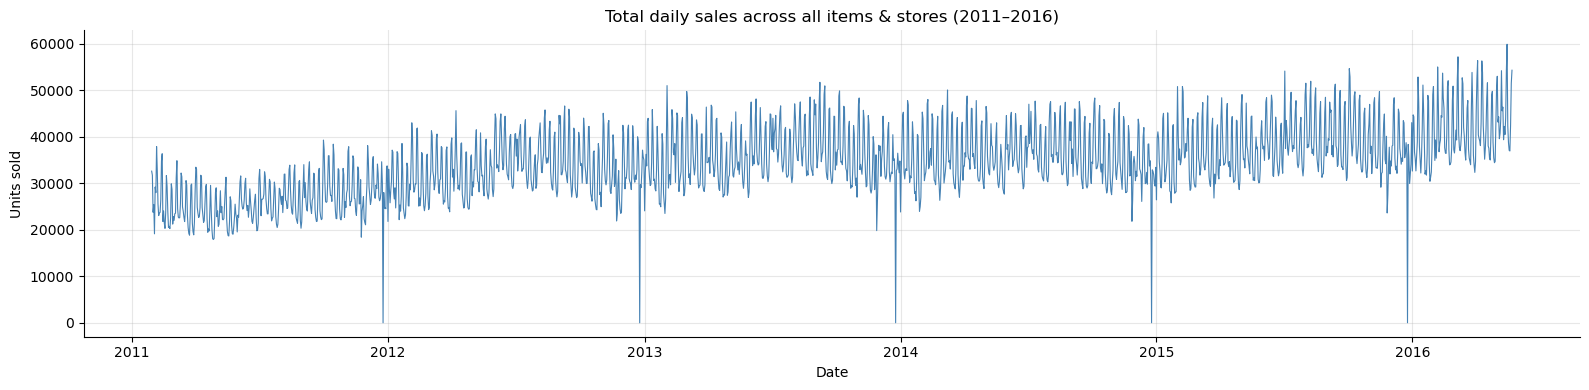

Average daily sales : 34,481
Peak sales day      : 2016-05-15 (59,921 units)
Lowest sales day    : 2012-12-25 (11 units)


In [26]:
# overall sales trend
daily = sales_long.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(16, 4))
plt.plot(daily['date'], daily['sales'], linewidth=0.8, color='steelblue')
plt.title('Total daily sales across all items & stores (2011–2016)')
plt.xlabel('Date')
plt.ylabel('Units sold')
plt.tight_layout()
plt.show()

print(f"Average daily sales : {daily['sales'].mean():,.0f}")
print(f"Peak sales day      : {daily.loc[daily['sales'].idxmax(), 'date'].date()} "
      f"({daily['sales'].max():,} units)")
print(f"Lowest sales day    : {daily.loc[daily['sales'].idxmin(), 'date'].date()} "
      f"({daily['sales'].min():,} units)")

In [27]:
# zero sale analysis
zero_sale=(sales_long['sales']==0).mean()
print(f"overall zero sale rate is:{zero_sale:.1%}")

overall zero sale rate is:68.0%


In [28]:
# zero sales per item analysis
item_zero=(
    sales_long.groupby('item_id')['sales']
    .apply(lambda x:(x==0).mean())
    .reset_index()
)
item_zero.columns=['item_id','zero_sales_rate']
item_zero

,item_id,zero_sales_rate
0,FOODS_1_001,0.651262
1,FOODS_1_002,0.731685
2,FOODS_1_003,0.625451
3,FOODS_1_004,0.344101
4,FOODS_1_005,0.547347
...,...,...
3044,HOUSEHOLD_2_512,0.648274
3045,HOUSEHOLD_2_513,0.785626
3046,HOUSEHOLD_2_514,0.862339
3047,HOUSEHOLD_2_515,0.950232


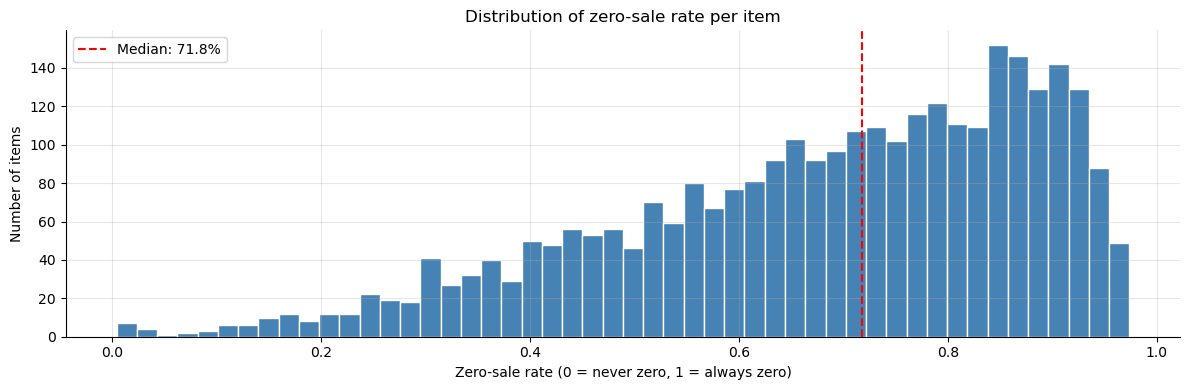

In [29]:
plt.figure(figsize=(12, 4))
plt.hist(item_zero['zero_sales_rate'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of zero-sale rate per item')
plt.xlabel('Zero-sale rate (0 = never zero, 1 = always zero)')
plt.ylabel('Number of items')
plt.axvline(item_zero['zero_sales_rate'].median(), color='red',
            linestyle='--', label=f"Median: {item_zero['zero_sales_rate'].median():.1%}")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
daily

,date,sales
0,2011-01-29,32631
1,2011-01-30,31749
2,2011-01-31,23783
3,2011-02-01,25412
4,2011-02-02,19146
...,...,...
1936,2016-05-18,37096
1937,2016-05-19,36963
1938,2016-05-20,42552
1939,2016-05-21,51518


In [31]:
agg=daily.set_index('date')['sales'].asfreq('D')
agg

date
2011-01-29    32631
2011-01-30    31749
2011-01-31    23783
2011-02-01    25412
2011-02-02    19146
              ...  
2016-05-18    37096
2016-05-19    36963
2016-05-20    42552
2016-05-21    51518
2016-05-22    54338
Freq: D, Name: sales, Length: 1941, dtype: int64

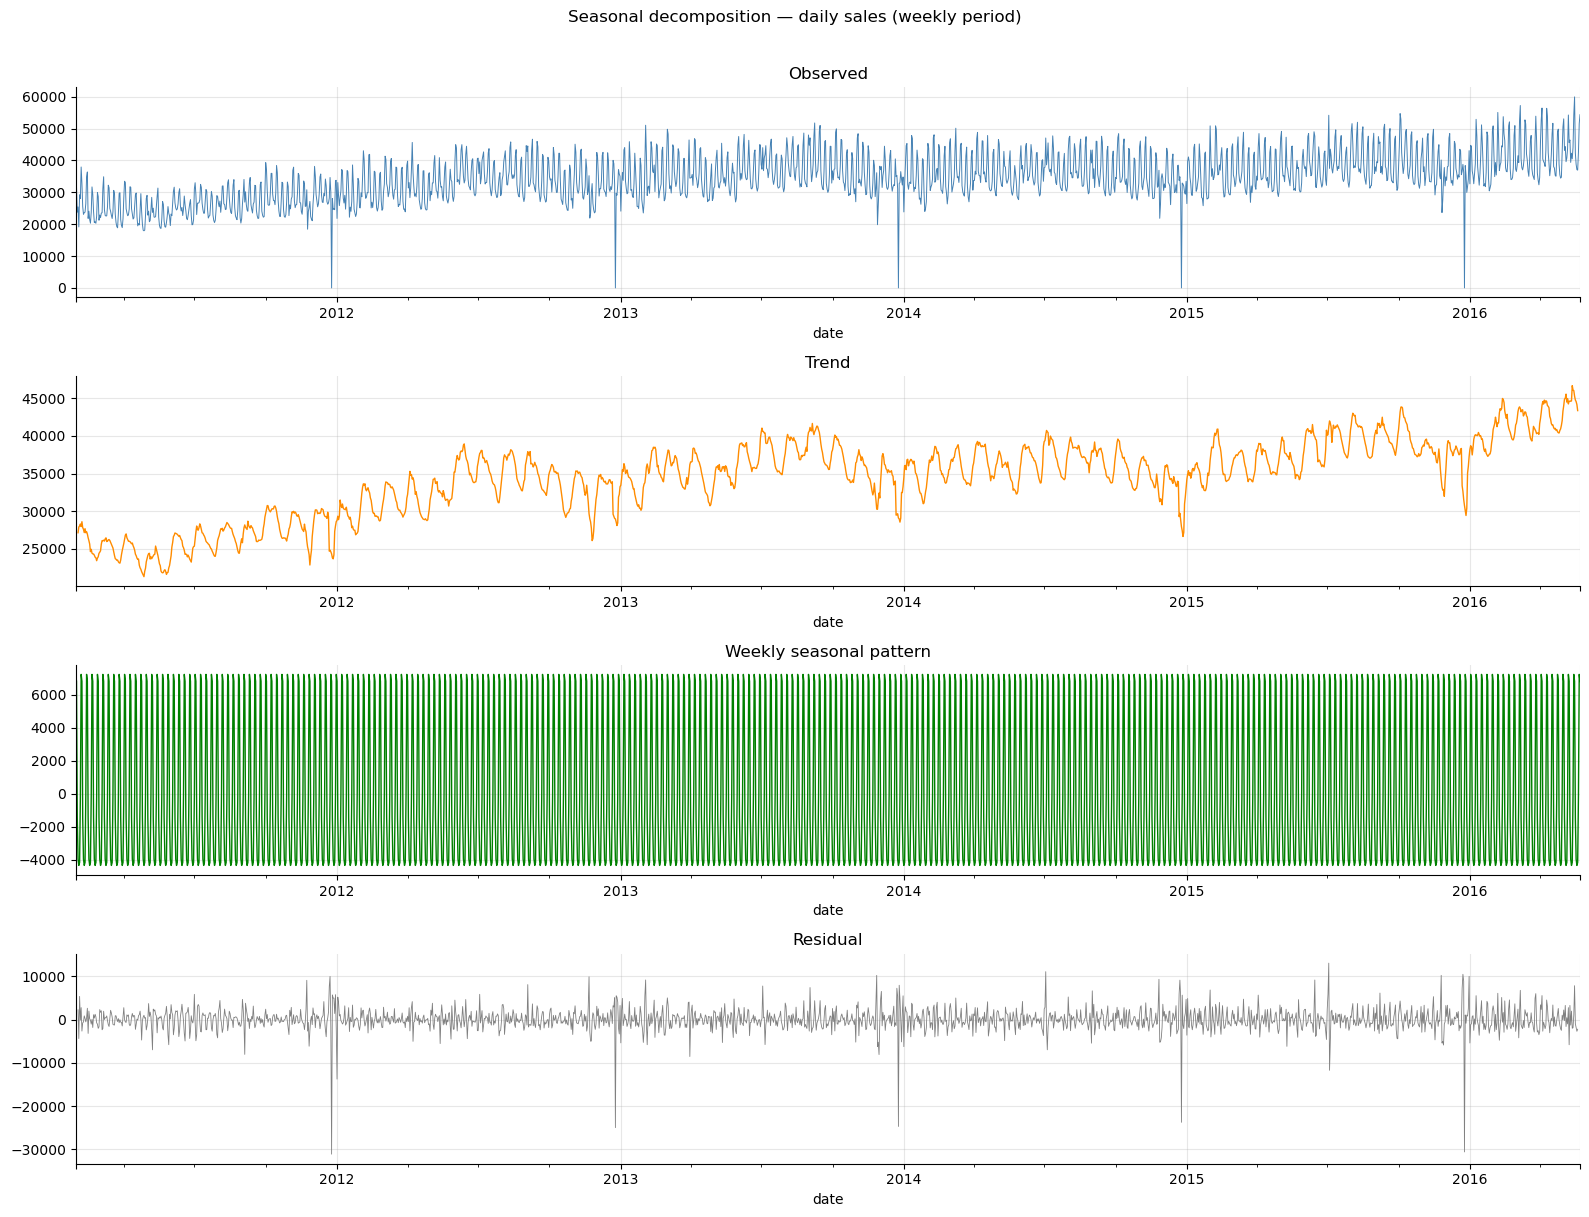

In [32]:
# weekly decomposition
week_decomp=seasonal_decompose(agg,model='additive',period=7)
fig, axes = plt.subplots(4, 1, figsize=(16, 12))
week_decomp.observed.plot(ax=axes[0], title='Observed',  color='steelblue', linewidth=0.7)
week_decomp.trend.plot(ax=axes[1],    title='Trend',     color='darkorange', linewidth=1)
week_decomp.seasonal.plot(ax=axes[2], title='Weekly seasonal pattern', color='green', linewidth=1)
week_decomp.resid.plot(ax=axes[3],    title='Residual',  color='gray', linewidth=0.6)
plt.suptitle('Seasonal decomposition — daily sales (weekly period)', y=1.01)
plt.tight_layout()
plt.show()

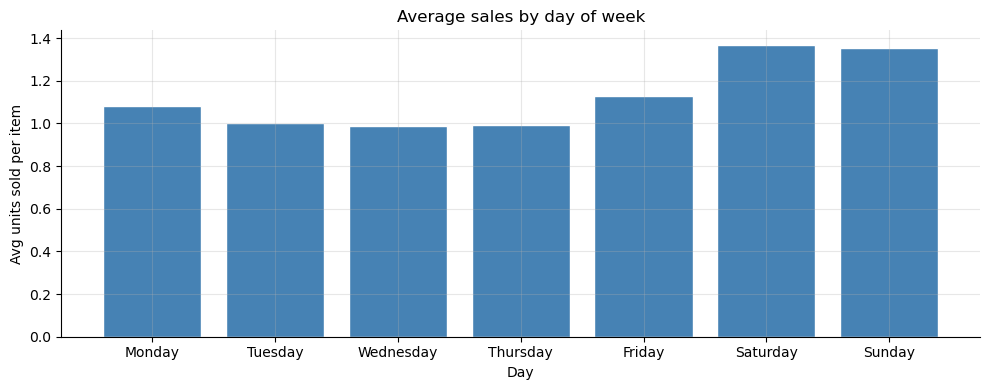

In [33]:
# day of week
sales_long['dayofweek']=sales_long['date'].dt.day_name()
dow_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow=(sales_long.groupby('dayofweek')['sales']
     .mean()
     .reindex(dow_order)
     .reset_index()
    )
plt.figure(figsize=(10,4))
plt.bar(dow['dayofweek'], dow['sales'], color='steelblue', edgecolor='white')
plt.title('Average sales by day of week')
plt.xlabel('Day')
plt.ylabel('Avg units sold per item')
plt.tight_layout()
plt.show()

In [34]:
# snap day trends


In [35]:
snap=sales_long.groupby('snap_CA')['sales'].agg(['mean','median','std']).reset_index()
snap


,snap_CA,mean,median,std
0,0,1.100260,0.0,3.770093
1,1,1.193148,0.0,4.064931


In [36]:
snap['snap_CA']=snap['snap_CA'].map({0:'Non Snap Day',1:'Snap Day'})
print("Snap day effect on Sales")
print(snap.to_string(index=False))

Snap day effect on Sales
     snap_CA     mean  median      std
Non Snap Day 1.100260     0.0 3.770093
    Snap Day 1.193148     0.0 4.064931


In [37]:
non_snap_mean=snap.loc[snap['snap_CA']=='Non Snap Day','mean'].values[0]
snap_mean=snap.loc[snap['snap_CA']=='Snap Day','mean'].values[0]
print(f"\nSNAP lift: {((snap_mean - non_snap_mean) / non_snap_mean) * 100:.1f}%")



SNAP lift: 8.4%


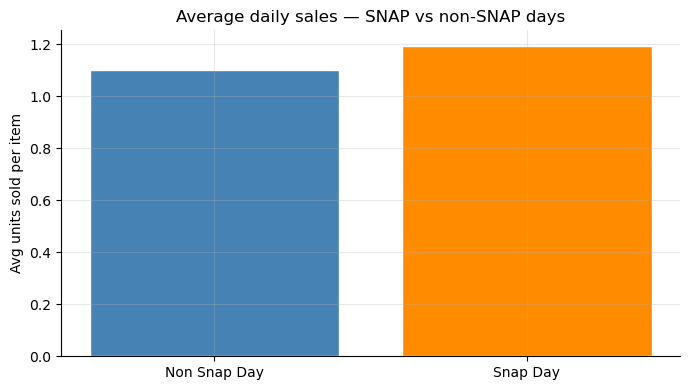

In [38]:
plt.figure(figsize=(7, 4))
plt.bar(snap['snap_CA'], snap['mean'], color=['steelblue','darkorange'], edgecolor='white')
plt.title('Average daily sales — SNAP vs non-SNAP days')
plt.ylabel('Avg units sold per item')
plt.tight_layout()
plt.show()

In [ ]:
# holiday and event effects

In [40]:
sales_long['event_name_1']=sales_long['event_name_1'].fillna('No event')
event_sales=(
    sales_long.groupby('event_name_1')['sales']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
no_event_avg=event_sales.loc[event_sales['event_name_1']=='No event','sales'].values[0]
top_events=event_sales.loc[event_sales['event_name_1']!='No event'].head(15)

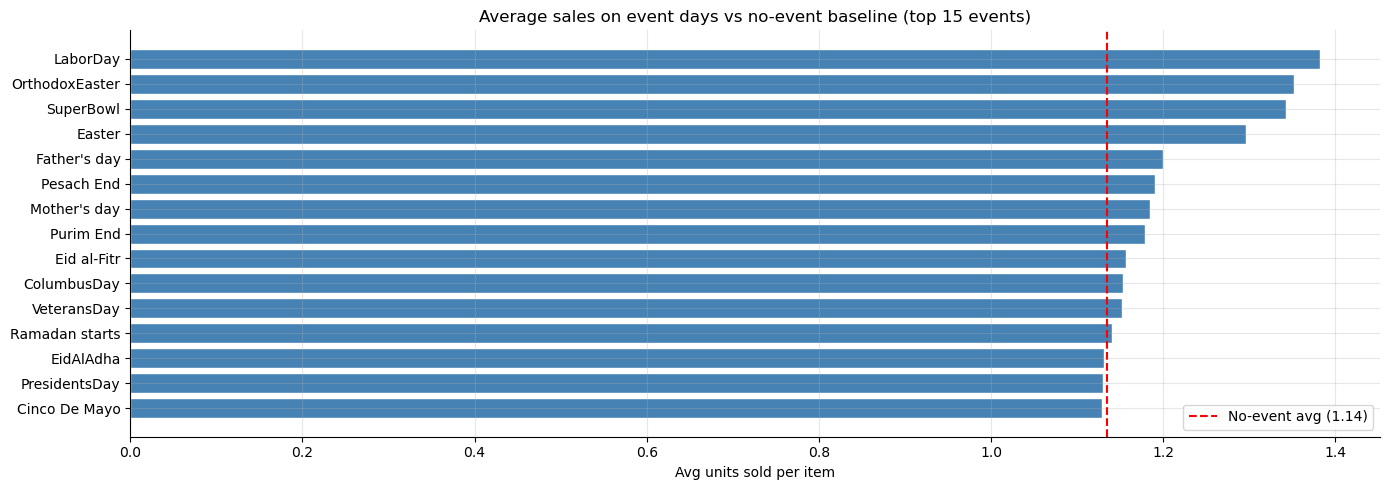

In [41]:


plt.figure(figsize=(14, 5))
bars = plt.barh(top_events['event_name_1'], top_events['sales'],
                color='steelblue', edgecolor='white')
plt.axvline(no_event_avg, color='red', linestyle='--',
            label=f'No-event avg ({no_event_avg:.2f})')
plt.title('Average sales on event days vs no-event baseline (top 15 events)')
plt.xlabel('Avg units sold per item')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [42]:
# price vs sales comparison

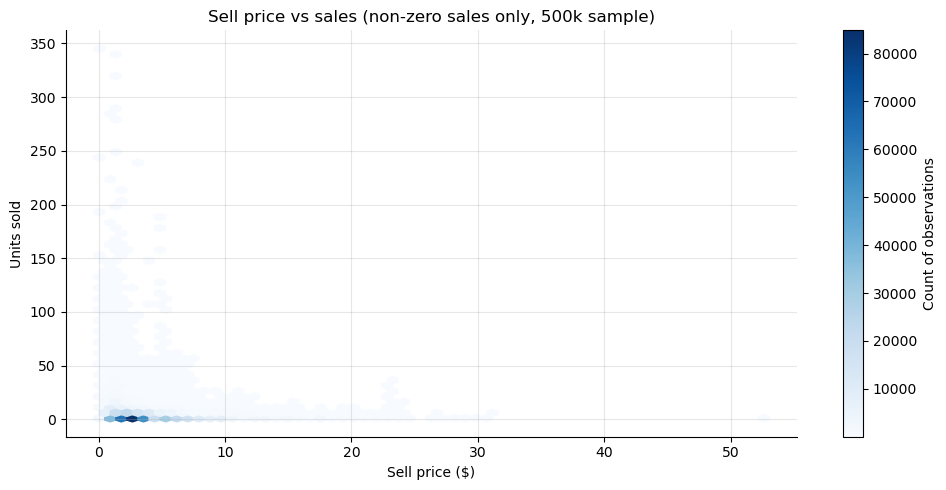

In [43]:
sample=sales_long[sales_long['sales']>0].sample(500_000,random_state=42)
plt.figure(figsize=(10, 5))
plt.hexbin(sample['sell_price'], sample['sales'],
           gridsize=60, cmap='Blues', mincnt=1)
plt.colorbar(label='Count of observations')
plt.title('Sell price vs sales (non-zero sales only, 500k sample)')
plt.xlabel('Sell price ($)')
plt.ylabel('Units sold')
plt.tight_layout()
plt.show()

In [44]:
corr=sales_long[['sales','sell_price']].corr().iloc[0,1]
print(f"Pearson correlation (price vs sales): {corr:.4f}")


Pearson correlation (price vs sales): -0.1313


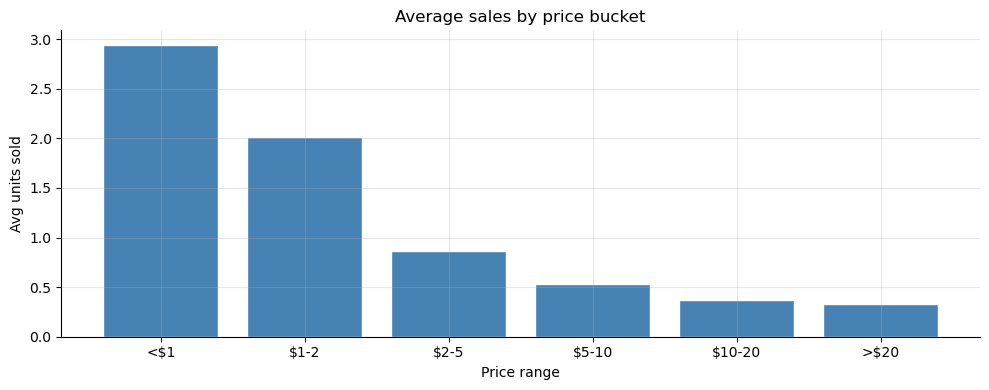

In [45]:
sales_long['price_bucket'] = pd.cut(sales_long['sell_price'],
                                     bins=[0,1,2,5,10,20,100],
                                     labels=['<$1','$1-2','$2-5','$5-10','$10-20','>$20'])
price_bucket = sales_long.groupby('price_bucket')['sales'].mean().reset_index()
plt.figure(figsize=(10, 4))
plt.bar(price_bucket['price_bucket'].astype(str), price_bucket['sales'],
        color='steelblue', edgecolor='white')
plt.title('Average sales by price bucket')
plt.xlabel('Price range')
plt.ylabel('Avg units sold')
plt.tight_layout()
plt.show()

In [46]:
print("=" * 55)
print("EDA SUMMARY — StockCast")
print("=" * 55)


n_items  = sales['item_id'].nunique()       
n_stores = sales['store_id'].nunique()       
date_min = sales_long['date'].min().date()
date_max = sales_long['date'].max().date()
n_rows   = len(sales_long)

avg_sales  = sales_long['sales'].mean()
zero_rate  = (sales_long['sales'] == 0).mean()
max_sale   = sales_long['sales'].max()

# events — use calendar directly (only 1,969 rows)
n_events = calendar['event_name_1'].dropna().nunique()

print(f"""
Dataset scope:
  Items         : {n_items:,}
  Stores        : {n_stores}
  Date range    : {date_min} → {date_max}
  Total rows    : {n_rows:,}

Sales characteristics:
  Avg daily sales/item : {avg_sales:.2f} units
  Zero-sale rate       : {zero_rate:.1%}
  Max single-day sale  : {max_sale} units

External covariate signals:
  SNAP lift            : {((snap_mean - non_snap_mean)/non_snap_mean)*100:.1f}%
  Price-sales corr     : {corr:.4f}
  Unique events        : {n_events}
""")
print("=" * 55)

EDA SUMMARY — StockCast

Dataset scope:
  Items         : 3,049
  Stores        : 10
  Date range    : 2011-01-29 → 2016-05-22
  Total rows    : 59,181,090

Sales characteristics:
  Avg daily sales/item : 1.13 units
  Zero-sale rate       : 68.0%
  Max single-day sale  : 763 units

External covariate signals:
  SNAP lift            : 8.4%
  Price-sales corr     : -0.1313
  Unique events        : 30

